# Folded Neighborhood Ablation And Conversion Analysis

This notebook trains five organoid-level 80/20 folds so that every organoid appears in validation exactly once. For each fold it trains one `GINCurvature` model, samples 2000 validation ego-subgraphs, and runs two perturbation families:

- **Ablation**: marker `Y` at hop distance `d` is set to zero.
- **Conversion**: marker `Y` at hop distance `d` is changed to marker `Z`.

Fold-specific influence maps are combined with count-weighted averages before plotting. The data loading, filtering, global feature handling, target transform, and training settings follow `experiments/train_single_model.ipynb`.


**Setup**


In [17]:
import copy
import json
import pickle
import random
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)
print("cuda         =", torch.cuda.is_available())


PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128
cuda         = True


**Settings**


In [ ]:
# Data and target settings
EXPERIMENT_GROUP = "ablation_analysis"
DATASET_NAME = "fixed_new"
TARGET_INDICES = [0]
TARGET_INDEX_FOR_ANALYSIS = 0
USE_GLOBAL_FEATURES = True
FILTER_BLACKLISTED_ORGANOIDS = True

# Optional target residualization against a train-only constant+globals baseline.
SUBTRACT_CONSTANT_GLOBAL_BASELINE = True

# Filtering and preprocessing settings from train_single_model.ipynb.
FILL_MISSING_COMPLEXITY = True
MISSING_COMPLEXITY_GROUP = {
    "dataset": "20251201",
    "timepoint": "day4p5",
    "fill_value": 2.1,
}
SPHERICITY_MAX = 0.92
SPHERICAL_MARKER_DIVERSITY_MIN = 0.5
COMPLEXITY_MIN = 2.0
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)
DAY3P5_TIMEPOINT = "day3p5"
TIMEPOINT_FILTER_MODE = "rest"  # "rest" excludes day3p5; "day3p5" keeps only day3p5; "all" disables this filter.

# Fold settings. Five 80/20 folds cover every organoid in validation once.
N_FOLDS = 5
FOLD_SEED = 42

# Model settings. One depth-4 model is trained per fold.
MODEL_CLASS = "GINCurvature"
NUM_LAYERS = 4
HIDDEN_DIM = 4 * 64
DROPOUT = 0.1
NORM = "batch"
RESIDUAL = True
BASELINE_HIDDEN_DIM = HIDDEN_DIM

# Training settings
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 2000
PATIENCE = 30
NUM_WORKERS = 4
EDGE_LOSS_WEIGHT = 0.20
EDGE_LOSS_PARAMS = {
    "weighted": False,
    "alpha": 2.0,
    "normalize_by": "graph_std",
    "clip_weight": 4.0,
}

# Perturbation settings
PERTURBATION_MODE = "single"
MAX_SUBGRAPHS_PER_FOLD = 2500
MIN_CENTER_COUNT = 50
MIN_PAIR_COUNT = 25
HEATMAP_MIN_COUNT = 5  # Set to an integer to draw low-count heatmap cells as white.
SUBGRAPH_SEED = 0
PERTURB_BATCH_SIZE = 128
NORMALIZE_BY = "perturbed_cells"

CONVERSION_SPECS = [
    {
        "key": "lysozyme_to_serotonin",
        "label": "Lysozyme -> Serotonin",
        "pairs": [("Lysozyme", "Serotonin")],
    },
    {
        "key": "serotonin_to_lysozyme",
        "label": "Serotonin -> Lysozyme",
        "pairs": [("Serotonin", "Lysozyme")],
    },
]

# Experiment output settings
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_NAME = f"folded_depth{NUM_LAYERS}_{RUN_TIMESTAMP}"
SAVE_DIR = PROJECT_ROOT / "results_experiments" / EXPERIMENT_GROUP / RUN_NAME
FIGURES_DIR = SAVE_DIR / "figures"
TABLES_DIR = SAVE_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


**Utility Helpers**


In [19]:
def safe_filename(name):
    text = str(name).strip().replace("/", "_")
    chars = [ch if (ch.isalnum() or ch in "._-") else "_" for ch in text]
    cleaned = "".join(chars).strip("._-")
    while "__" in cleaned:
        cleaned = cleaned.replace("__", "_")
    return cleaned or "figure"


def save_mpl_figure(fig, name, *, dpi=300, close=False):
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    paths = []
    for suffix in ["pdf", "png"]:
        path = FIGURES_DIR / f"{safe_filename(name)}.{suffix}"
        fig.savefig(path, bbox_inches="tight", dpi=dpi)
        paths.append(path)
    print(f"Saved figure -> {paths[0]} and {paths[1]}")
    if close:
        plt.close(fig)
    return paths


def select_target_column(values, target_index=0):
    arr = np.asarray(values)
    if arr.ndim == 1:
        return arr.reshape(-1)
    if arr.ndim == 2 and arr.shape[1] == 1:
        return arr[:, 0]
    if arr.ndim == 2:
        return arr[:, int(target_index)]
    raise ValueError(f"Expected 1-D or 2-D target array, got shape {arr.shape}")


def jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [jsonable(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, torch.dtype):
        return str(obj)
    if isinstance(obj, np.dtype):
        return str(obj)
    return obj


## 1. Load, Filter, And Prepare The Dataset


In [20]:
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import (
    add_log_metadata_features,
    attach_metadata_to_graphs,
    fill_missing_metadata_for_group,
    infer_global_dim,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
    print_graph_and_metadata_fields,
    promote_metadata_to_graph_tensors,
    snapshot_graph_metadata,
    strip_graph_metadata,
)
from src.data.filters import (
    filter_graphs_by_blacklist,
    filter_graphs_by_marker_diversity,
    filter_graphs_by_metadata,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
    load_graph_blacklist_from_dir,
)
from src.data.preprocessing import interpolate_target_outliers_from_neighbors
from src.data.splits import graph_metadata_key
from src.data.target_transforms import (
    AsinhStandardizeTransform,
    ChainedTargetTransform,
    GlobalBaselineResidualTransform,
    standardize_graph_global_features,
)
from src.models.gnn import GINCurvature
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term
from src.inference.predict import predict_targets
from src.data.subgraphs import build_ego_subgraphs_for_dataset
from src.data.subgraph_sampling import sample_subgraphs_coverage, print_sampling_summary
from src.analysis.perturbation import (
    compute_perturbation_influence_maps,
    compute_conversion_influence_maps,
)
from src.plotting.influence_maps import plot_influence_heatmap, plot_influence_center_resolved


In [21]:
data_dir = DATA_ROOT / DATASET_NAME
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")
if graphs:
    print("Raw y shape:", tuple(graphs[0].y.shape))

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(graphs, meta, exclude_keys=None)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
if graphs:
    print("Selected y shape:", tuple(graphs[0].y.shape))

marker_names = load_marker_names_from_dir(str(data_dir))
if marker_names is None:
    n_markers = int(graphs[0].x.size(1)) if graphs else 0
    marker_names = [f"marker_{i}" for i in range(n_markers)]
print(f"Loaded {len(marker_names)} markers:", marker_names)

print_graph_and_metadata_fields(graphs)


Loaded 1423 graphs; skipped 0.
Loaded 1423 organoids.
Raw y shape: (165, 2)
Attached metadata to 1423/1423 graphs.
Selected y shape: (165,)
Loaded 7 markers: ['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin']
Graph fields:
  - _edge_attr_cls
  - _store
  - _tensor_attr_cls

Metadata fields (g.meta):
  - cell_patch_area
  - complexity
  - d_crypts_graph
  - d_crypts_mesh_shape
  - dataset
  - deleted_node_ids
  - graph_path
  - kept_node_ids
  - label_uid
  - mean_gaussian_curvature
  - mean_mean_curvature
  - mesh_path
  - new_to_old_index
  - num_deleted_nodes
  - num_nodes
  - old_to_new_index
  - organoid_id
  - original_num_nodes
  - proj_vertex_ids
  - segmentation_path
  - timepoint
  - total_curvature_discrete
  - total_mean_curvature_discrete
  - total_surface_area
  - total_volume
  - voronoi_vertex_owner
  - y_columns


In [22]:
# Timepoint selection. Default matches train_single_model.ipynb by excluding day3p5.
if TIMEPOINT_FILTER_MODE == "rest":
    graphs = filter_graphs_by_metadata(
        graphs,
        key="timepoint",
        drop_values={DAY3P5_TIMEPOINT},
        missing="keep",
        inplace=False,
        print_summary=True,
    )
elif TIMEPOINT_FILTER_MODE == "day3p5":
    graphs = filter_graphs_by_metadata(
        graphs,
        key="timepoint",
        keep_values={DAY3P5_TIMEPOINT},
        missing="drop",
        inplace=False,
        print_summary=True,
    )
elif TIMEPOINT_FILTER_MODE in (None, "all"):
    print("Timepoint filtering disabled.")
else:
    raise ValueError('TIMEPOINT_FILTER_MODE must be one of: "rest", "day3p5", or "all".')

if FILTER_BLACKLISTED_ORGANOIDS:
    blacklist = load_graph_blacklist_from_dir(data_dir)
    graphs = filter_graphs_by_blacklist(
        graphs,
        blacklist,
        print_summary=True,
    )
else:
    blacklist = set()
    print("Blacklist filtering disabled.")

if FILL_MISSING_COMPLEXITY:
    graphs = fill_missing_metadata_for_group(
        graphs,
        field="complexity",
        fill_value=MISSING_COMPLEXITY_GROUP["fill_value"],
        dataset=MISSING_COMPLEXITY_GROUP["dataset"],
        timepoint=MISSING_COMPLEXITY_GROUP["timepoint"],
    )

graphs, g_spherical = filter_graphs_by_sphericity(
    graphs,
    max_sphericity=SPHERICITY_MAX,
    print_summary=True,
    return_rejected=True,
)

g_spherical = filter_graphs_by_marker_diversity(
    g_spherical,
    min_score=SPHERICAL_MARKER_DIVERSITY_MIN,
    print_summary=True,
)

graphs = filter_graphs_by_numeric_metadata(
    graphs,
    key="complexity",
    min_value=COMPLEXITY_MIN,
    allow_missing=False,
    inplace=False,
    print_summary=True,
)

# Match train_single_model.ipynb: spherical rejected graphs are not added back by default.
# graphs = graphs + g_spherical
print(f"After filtering: {len(graphs)} organoids.")

if INTERPOLATE_TARGET_OUTLIERS:
    graphs, outlier_info = interpolate_target_outliers_from_neighbors(
        graphs,
        clip_quantiles=OUTLIER_CLIP_QUANTILES,
    )
else:
    outlier_info = None


filter_graphs_by_metadata(key='timepoint'): kept 1134 / 1423 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day3p5                0    289    0.000
20250929         day4                342    342    1.000
20250929         day4p5              104    104    1.000
20250929         day4p5-more         411    411    1.000
20251201         day4p5              277    277    1.000
filter_graphs_by_blacklist(n_keys=6): kept 1128 / 1134 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                341    342    0.997
20250929         day4p5              104    104    1.000
20250929         day4p5-more         409    411    0.995
20251201         day4p5              274    277    0.989
filter_graphs_by_sphericity(max_sphericity=0.92): kept 813 / 1128 graphs

dataset          timepoint          kept  total  

## 2. Five Organoid-Level Folds


In [23]:
def make_organoid_kfolds(graphs_in, *, n_folds=5, seed=0):
    if len(graphs_in) < n_folds:
        raise ValueError(f"Need at least {n_folds} graphs for {n_folds} folds, got {len(graphs_in)}.")
    keys = [graph_metadata_key(g) for g in graphs_in]
    if len(set(keys)) != len(keys):
        raise ValueError("Expected one graph per organoid key; duplicate graph_metadata_key values found.")

    rng = np.random.default_rng(seed)
    indices = np.arange(len(graphs_in), dtype=int)
    rng.shuffle(indices)
    fold_indices = np.array_split(indices, n_folds)

    folds = []
    all_val_indices = []
    for fold_id, val_idx in enumerate(fold_indices):
        val_idx = np.asarray(val_idx, dtype=int)
        val_set = set(val_idx.tolist())
        train_idx = np.asarray([i for i in range(len(graphs_in)) if i not in val_set], dtype=int)
        folds.append({
            "fold": int(fold_id),
            "train_indices": train_idx,
            "val_indices": val_idx,
            "train_keys": [keys[int(i)] for i in train_idx],
            "val_keys": [keys[int(i)] for i in val_idx],
        })
        all_val_indices.extend(val_idx.tolist())

    assert sorted(all_val_indices) == list(range(len(graphs_in))), "Validation folds do not cover the dataset exactly once."
    return folds


folds = make_organoid_kfolds(graphs, n_folds=N_FOLDS, seed=FOLD_SEED)
fold_summary_df = pd.DataFrame([
    {
        "fold": f["fold"],
        "n_train_graphs": len(f["train_indices"]),
        "n_val_graphs": len(f["val_indices"]),
    }
    for f in folds
])
display(fold_summary_df)


,fold,n_train_graphs,n_val_graphs
0,0,564,142
1,1,565,141
2,2,565,141
3,3,565,141
4,4,565,141


## 3. Fold Preparation, Model Training, And Perturbations


In [24]:
field_specs = [
    {
        "meta_keys": [
            "log_surface_area",
            "log_volume",
            "log_volume_over_area",
            "log_num_cells",
        ],
        "attr_name": "global_feat",
        "kind": "graph_vector",
        "dtype": torch.float32,
    },
]


def prepare_fold_graphs(train_graphs, val_graphs):
    g_train = copy.deepcopy(train_graphs)
    g_val = copy.deepcopy(val_graphs)

    if USE_GLOBAL_FEATURES:
        g_train = add_log_metadata_features(g_train, inplace=False)
        g_val = add_log_metadata_features(g_val, inplace=False)
        g_train = promote_metadata_to_graph_tensors(g_train, field_specs, inplace=False)
        g_val = promote_metadata_to_graph_tensors(g_val, field_specs, inplace=False)

    train_meta_lookup = snapshot_graph_metadata(g_train)
    val_meta_lookup = snapshot_graph_metadata(g_val)

    g_train = strip_graph_metadata(g_train, inplace=False)
    g_val = strip_graph_metadata(g_val, inplace=False)

    center_global, scale_global = None, None
    if USE_GLOBAL_FEATURES:
        center_global, scale_global = standardize_graph_global_features(
            g_train,
            g_val,
            attr_name="global_feat",
            robust=False,
        )

    if SUBTRACT_CONSTANT_GLOBAL_BASELINE:
        if not USE_GLOBAL_FEATURES:
            raise ValueError("SUBTRACT_CONSTANT_GLOBAL_BASELINE requires USE_GLOBAL_FEATURES=True.")
        baseline_residual_transform = GlobalBaselineResidualTransform(num_workers=NUM_WORKERS)
        target_transform = ChainedTargetTransform([
            baseline_residual_transform,
            AsinhStandardizeTransform(robust=True),
        ])
    else:
        baseline_residual_transform = None
        target_transform = AsinhStandardizeTransform(robust=True)

    target_transform.fit(g_train)
    target_transform.transform_graphs(g_train, in_place=True)
    target_transform.transform_graphs(g_val, in_place=True)

    return {
        "g_train": g_train,
        "g_val": g_val,
        "train_meta_lookup": train_meta_lookup,
        "val_meta_lookup": val_meta_lookup,
        "center_global": center_global,
        "scale_global": scale_global,
        "target_transform": target_transform,
        "baseline_residual_transform": baseline_residual_transform,
    }


def make_gin_model(g_train):
    return GINCurvature(
        n_markers=int(g_train[0].x.size(1)),
        global_dim=infer_global_dim(g_train),
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        residual=RESIDUAL,
        norm=NORM,
    )


def make_train_config():
    aux_losses = [
        WeightedLossTerm(
            name="edge",
            fn=edge_loss_term,
            weight=EDGE_LOSS_WEIGHT,
            params=EDGE_LOSS_PARAMS,
        ),
    ]
    return TrainConfig(
        lr=LR,
        batch_size=BATCH_SIZE,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        num_workers=NUM_WORKERS,
        aux_losses=aux_losses,
    )


In [25]:
def validate_conversion_markers(conversion_specs, marker_names):
    missing = []
    marker_set = set(marker_names)
    for spec in conversion_specs:
        for source, target in spec["pairs"]:
            if source not in marker_set:
                missing.append(source)
            if target not in marker_set:
                missing.append(target)
    if missing:
        raise ValueError(f"Conversion markers not found in marker_names: {sorted(set(missing))}")


validate_conversion_markers(CONVERSION_SPECS, marker_names)


In [26]:
fold_results = []
training_logs = []
prediction_summaries = []
sampling_results = []

for fold in folds:
    fold_id = int(fold["fold"])
    print("\n" + "=" * 90)
    print(f"Fold {fold_id + 1}/{N_FOLDS}")

    raw_train = [graphs[int(i)] for i in fold["train_indices"]]
    raw_val = [graphs[int(i)] for i in fold["val_indices"]]
    pack = prepare_fold_graphs(raw_train, raw_val)

    g_train = pack["g_train"]
    g_val = pack["g_val"]
    target_transform = pack["target_transform"]

    model = make_gin_model(g_train)
    cfg = make_train_config()
    model, metrics, history = train(model, g_train, g_val, cfg)

    training_logs.append({
        "fold": fold_id,
        "metrics": metrics,
        "history": history,
        "train_keys": fold["train_keys"],
        "val_keys": fold["val_keys"],
    })

    y_true, y_pred, _ = predict_targets(
        g_val,
        model,
        batch_size=BATCH_SIZE,
        target_transform=target_transform,
    )
    y_true = select_target_column(y_true, TARGET_INDEX_FOR_ANALYSIS)
    y_pred = select_target_column(y_pred, TARGET_INDEX_FOR_ANALYSIS)
    prediction_summaries.append({
        "fold": fold_id,
        "n_val_nodes": int(len(y_true)),
        "val_mse": float(np.mean((y_pred - y_true) ** 2)),
        "val_mae": float(np.mean(np.abs(y_pred - y_true))),
        "n_train_graphs": len(g_train),
        "n_val_graphs": len(g_val),
    })

    print(f"Building validation ego-subgraphs for fold {fold_id}.")
    val_subgraphs = build_ego_subgraphs_for_dataset(
        g_val,
        num_hops=NUM_LAYERS,
        max_centers_per_graph=None,
        seed=SUBGRAPH_SEED + fold_id,
        copy_graph_level_attrs=True,
    )

    sampled_val_subgraphs, sample_info = sample_subgraphs_coverage(
        val_subgraphs,
        marker_names=marker_names,
        k_hops=NUM_LAYERS,
        max_subgraphs=MAX_SUBGRAPHS_PER_FOLD,
        min_center_count=MIN_CENTER_COUNT,
        min_pair_count=MIN_PAIR_COUNT,
        seed=SUBGRAPH_SEED + fold_id,
    )
    print_sampling_summary(sample_info, marker_names)
    sampling_results.append({"fold": fold_id, "sample_info": sample_info})

    print(f"Running ablation perturbations on {len(sampled_val_subgraphs)} sampled validation subgraphs.")
    ablation_res = compute_perturbation_influence_maps(
        subgraphs=sampled_val_subgraphs,
        model=model,
        marker_names=marker_names,
        k_hops=NUM_LAYERS,
        mode=PERTURBATION_MODE,
        max_subgraphs=None,
        batch_size=PERTURB_BATCH_SIZE,
        target_index=TARGET_INDEX_FOR_ANALYSIS,
        target_transform=target_transform,
        normalize_by=NORMALIZE_BY,
    )

    conversion_results = {}
    for spec in CONVERSION_SPECS:
        print(f"Running conversion perturbation: {spec['label']}")
        conversion_results[spec["key"]] = compute_conversion_influence_maps(
            subgraphs=sampled_val_subgraphs,
            model=model,
            marker_names=marker_names,
            k_hops=NUM_LAYERS,
            conversion_pairs=spec["pairs"],
            mode=PERTURBATION_MODE,
            max_subgraphs=None,
            batch_size=PERTURB_BATCH_SIZE,
            target_index=TARGET_INDEX_FOR_ANALYSIS,
            target_transform=target_transform,
            normalize_by=NORMALIZE_BY,
        )

    fold_results.append({
        "fold": fold_id,
        "ablation": ablation_res,
        "conversions": conversion_results,
        "n_sampled_subgraphs": len(sampled_val_subgraphs),
    })

prediction_summary_df = pd.DataFrame(prediction_summaries)
display(prediction_summary_df)
print("Finished folded analysis.")



Fold 1/5
epoch 001 | train loss 0.6360 mae 0.8182 | val loss 0.4978 mae 0.7695
epoch 002 | train loss 0.5399 mae 0.7570 | val loss 0.4981 mae 0.7664
epoch 003 | train loss 0.4984 mae 0.7379 | val loss 0.4814 mae 0.7576
epoch 004 | train loss 0.4719 mae 0.7214 | val loss 0.4717 mae 0.7536
epoch 005 | train loss 0.4484 mae 0.7102 | val loss 0.4546 mae 0.7403
epoch 006 | train loss 0.4335 mae 0.7008 | val loss 0.4359 mae 0.7271
epoch 007 | train loss 0.4204 mae 0.6936 | val loss 0.4173 mae 0.7183
epoch 008 | train loss 0.4077 mae 0.6868 | val loss 0.4339 mae 0.7271
epoch 009 | train loss 0.3959 mae 0.6792 | val loss 0.4052 mae 0.7090
epoch 010 | train loss 0.3872 mae 0.6748 | val loss 0.4426 mae 0.7343
epoch 011 | train loss 0.3801 mae 0.6702 | val loss 0.4083 mae 0.7100
epoch 012 | train loss 0.3768 mae 0.6699 | val loss 0.3703 mae 0.6837
epoch 013 | train loss 0.3708 mae 0.6650 | val loss 0.3757 mae 0.6863
epoch 014 | train loss 0.3647 mae 0.6616 | val loss 0.4067 mae 0.7076
epoch 015 

,fold,n_val_nodes,val_mse,val_mae,n_train_graphs,n_val_graphs
0,0,65245,0.002099,0.031057,564,142
1,1,68469,0.001996,0.030062,565,141
2,2,72716,0.001935,0.030101,565,141
3,3,68273,0.001876,0.029294,565,141
4,4,63680,0.002139,0.030987,565,141


Finished folded analysis.


## 4. Combine Fold Results


In [27]:
def denominator_array(result, count_key, case_key):
    if NORMALIZE_BY == "perturbed_cells":
        return np.asarray(result[count_key], dtype=np.float64)
    if NORMALIZE_BY == "cases":
        return np.asarray(result[case_key], dtype=np.float64)
    raise ValueError(f"Unknown NORMALIZE_BY={NORMALIZE_BY!r}")


def combine_weighted_results(results, value_keys, count_key, case_key):
    combined = {}
    total_counts = None
    total_cases = None
    total_denom = None

    for result in results:
        counts = np.asarray(result[count_key], dtype=np.int64)
        cases = np.asarray(result[case_key], dtype=np.int64)
        denom = denominator_array(result, count_key, case_key)
        if total_counts is None:
            total_counts = np.zeros_like(counts, dtype=np.int64)
            total_cases = np.zeros_like(cases, dtype=np.int64)
            total_denom = np.zeros_like(denom, dtype=np.float64)
        total_counts += counts
        total_cases += cases
        total_denom += denom

    combined[count_key] = total_counts
    combined[case_key] = total_cases

    for key in value_keys:
        weighted_sum = None
        for result in results:
            values = np.asarray(result[key], dtype=np.float64)
            denom = denominator_array(result, count_key, case_key)
            contribution = values * denom
            if weighted_sum is None:
                weighted_sum = np.zeros_like(contribution, dtype=np.float64)
            weighted_sum += contribution
        out = np.full_like(weighted_sum, np.nan, dtype=np.float64)
        mask = total_denom > 0
        out[mask] = weighted_sum[mask] / total_denom[mask]
        combined[key] = out

    return combined


def combine_ablation_fold_results(fold_results):
    results = [entry["ablation"] for entry in fold_results]
    total = combine_weighted_results(
        results,
        ["delta_mu_total", "delta_mu_abs_total", "delta_lv_total", "delta_lv_abs_total"],
        "counts_total",
        "cases_total",
    )
    cmarker = combine_weighted_results(
        results,
        ["delta_mu_cmarker", "delta_mu_abs_cmarker", "delta_lv_cmarker", "delta_lv_abs_cmarker"],
        "counts_cmarker",
        "cases_cmarker",
    )
    out = {**total, **cmarker}
    out.update({
        "hops": results[0]["hops"],
        "marker_names": results[0]["marker_names"],
        "target_index": results[0]["target_index"],
        "prediction_scale": results[0]["prediction_scale"],
        "normalize_total_by": NORMALIZE_BY,
        "normalize_center_by": NORMALIZE_BY,
    })
    return out


def combine_conversion_fold_results(fold_results, spec_key):
    results = [entry["conversions"][spec_key] for entry in fold_results]
    total = combine_weighted_results(
        results,
        ["delta_mu_total", "delta_mu_abs_total", "delta_lv_total", "delta_lv_abs_total"],
        "counts_total",
        "cases_total",
    )
    cmarker = combine_weighted_results(
        results,
        ["delta_mu_cmarker", "delta_mu_abs_cmarker", "delta_lv_cmarker", "delta_lv_abs_cmarker"],
        "counts_cmarker",
        "cases_cmarker",
    )
    out = {**total, **cmarker}
    out.update({
        "hops": results[0]["hops"],
        "marker_names": results[0]["marker_names"],
        "conversion_pairs": results[0]["conversion_pairs"],
        "conversion_pair_labels": results[0]["conversion_pair_labels"],
        "target_index": results[0]["target_index"],
        "prediction_scale": results[0]["prediction_scale"],
        "normalize_total_by": NORMALIZE_BY,
        "normalize_center_by": NORMALIZE_BY,
    })
    return out


combined_ablation = combine_ablation_fold_results(fold_results)
combined_conversions = {
    spec["key"]: combine_conversion_fold_results(fold_results, spec["key"])
    for spec in CONVERSION_SPECS
}

print("Combined ablation total shape:", combined_ablation["delta_mu_total"].shape)
for spec in CONVERSION_SPECS:
    print(spec["label"], combined_conversions[spec["key"]]["delta_mu_total"].shape)


Combined ablation total shape: (5, 7)
Lysozyme -> Serotonin (5, 7, 7)
Serotonin -> Lysozyme (5, 7, 7)


## 5. Ablation Heatmaps


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/ablation_analysis/folded_depth5_20260605_165612/figures/fold_combined_ablation_delta_mu_total.pdf and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/ablation_analysis/folded_depth5_20260605_165612/figures/fold_combined_ablation_delta_mu_total.png


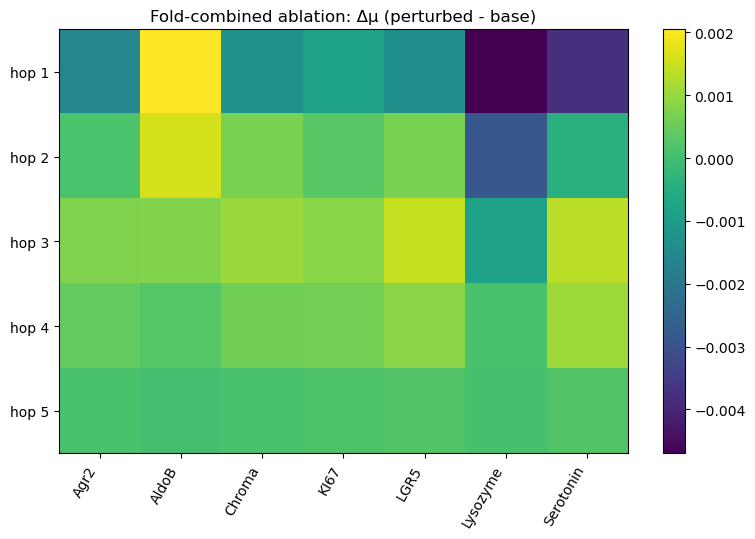

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/ablation_analysis/folded_depth5_20260605_165612/figures/fold_combined_ablation_delta_logvar_total.pdf and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/ablation_analysis/folded_depth5_20260605_165612/figures/fold_combined_ablation_delta_logvar_total.png


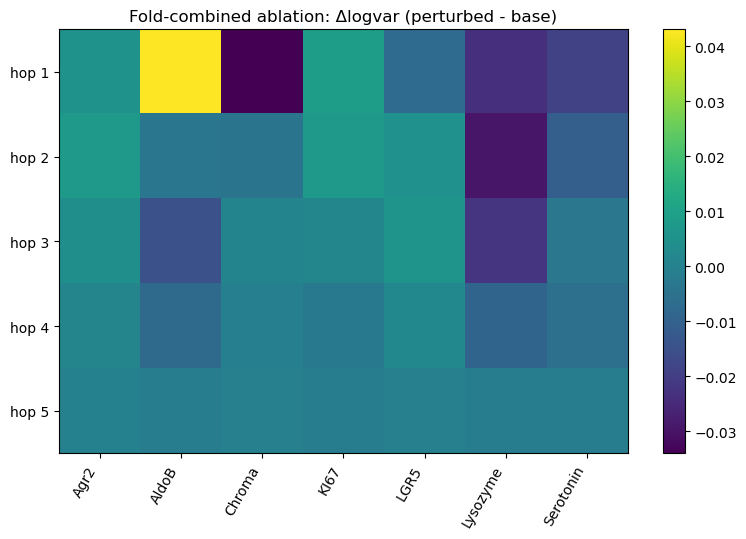

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/ablation_analysis/folded_depth5_20260605_165612/figures/fold_combined_ablation_delta_mu_center_resolved.pdf and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/ablation_analysis/folded_depth5_20260605_165612/figures/fold_combined_ablation_delta_mu_center_resolved.png


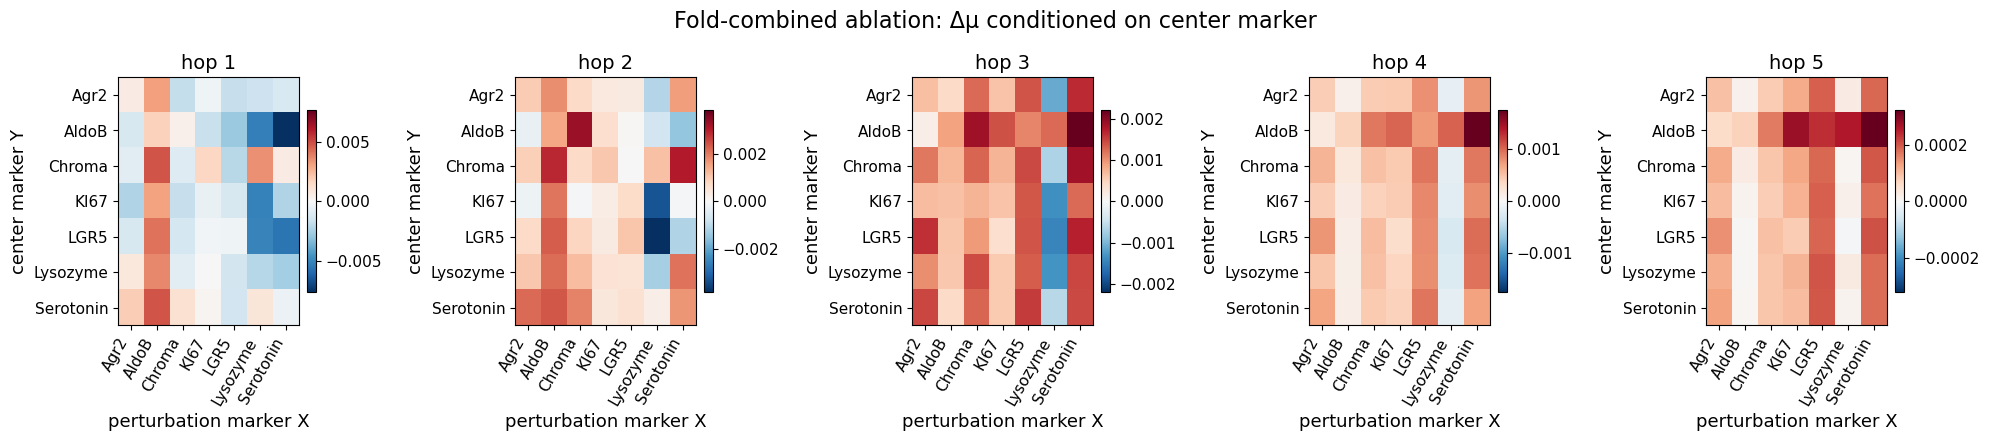

In [28]:
fig, axes = plot_influence_heatmap(
    combined_ablation["delta_mu_total"],
    combined_ablation["hops"],
    combined_ablation["marker_names"],
    title="Fold-combined ablation: Δμ (perturbed - base)",
    counts=combined_ablation["counts_total"],
    min_count=HEATMAP_MIN_COUNT,
)
save_mpl_figure(fig, "fold_combined_ablation_delta_mu_total")
plt.show()

fig, axes = plot_influence_heatmap(
    combined_ablation["delta_lv_total"],
    combined_ablation["hops"],
    combined_ablation["marker_names"],
    title="Fold-combined ablation: Δlogvar (perturbed - base)",
    counts=combined_ablation["counts_total"],
    min_count=HEATMAP_MIN_COUNT,
)
save_mpl_figure(fig, "fold_combined_ablation_delta_logvar_total")
plt.show()

fig, axes = plot_influence_center_resolved(
    combined_ablation["delta_mu_cmarker"],
    combined_ablation["hops"],
    combined_ablation["marker_names"],
    title="Fold-combined ablation: Δμ conditioned on center marker",
    sort_center=False,
    center_zero=True,
    cmap="RdBu_r",
    counts=combined_ablation["counts_cmarker"],
    min_count=HEATMAP_MIN_COUNT,
)
save_mpl_figure(fig, "fold_combined_ablation_delta_mu_center_resolved")
plt.show()


## 6. Conversion Heatmaps And Total Δμ Curves

Center-resolved conversion heatmaps are shown for each remaining single-pair conversion. The total Δμ comparison is plotted as one stacked figure: each panel overlays the conversion curve with the matching source-marker ablation curve.


In [29]:
def marker_index(name):
    marker_names_list = list(marker_names)
    if name in marker_names_list:
        return marker_names_list.index(name)
    lower = {str(m).lower(): i for i, m in enumerate(marker_names_list)}
    key = str(name).lower()
    if key not in lower:
        raise ValueError(f"Marker {name!r} not found in marker_names.")
    return lower[key]


def spec_pair_indices(spec):
    return [(marker_index(source), marker_index(target)) for source, target in spec["pairs"]]


def mask_low_count_values(values, counts, min_count):
    values = np.asarray(values, dtype=float)
    if min_count is None:
        return values
    if counts is None:
        raise ValueError("counts must be provided when min_count is not None.")
    counts = np.asarray(counts)
    if counts.shape != values.shape:
        raise ValueError(f"counts shape {counts.shape} does not match values shape {values.shape}.")
    masked = values.copy()
    masked[counts < min_count] = np.nan
    return masked


def cmap_with_bad_color(cmap="RdBu_r", bad_color="white"):
    cmap_obj = plt.get_cmap(cmap).copy() if isinstance(cmap, str) else cmap.copy()
    cmap_obj.set_bad(bad_color)
    return cmap_obj


def weighted_average_from_pairs(values, weights, pairs):
    weighted_sum = np.zeros(values.shape[:1], dtype=np.float64)
    weight_sum = np.zeros(values.shape[:1], dtype=np.float64)
    for source, target in pairs:
        v = values[:, source, target]
        w = weights[:, source, target]
        valid = (w > 0) & np.isfinite(v)
        weighted_sum[valid] += v[valid] * w[valid]
        weight_sum[valid] += w[valid]

    out = np.full_like(weighted_sum, np.nan, dtype=np.float64)
    valid = weight_sum > 0
    out[valid] = weighted_sum[valid] / weight_sum[valid]
    return out, weight_sum


def weighted_spec_total_curve(result, spec, value_key):
    pairs = spec_pair_indices(spec)
    values = np.asarray(result[value_key], dtype=np.float64)  # H, source, target
    denom = denominator_array(result, "counts_total", "cases_total")
    counts = np.asarray(result["counts_total"], dtype=np.int64)

    curve, denom_sum = weighted_average_from_pairs(values, denom, pairs)
    count_sum = np.zeros(values.shape[:1], dtype=np.int64)
    for source, target in pairs:
        count_sum += counts[:, source, target]
    return curve, denom_sum, count_sum


def weighted_spec_center_map(result, spec, value_key, *, return_counts=False):
    pairs = spec_pair_indices(spec)
    values = np.asarray(result[value_key], dtype=np.float64)  # H, center, source, target
    denom = denominator_array(result, "counts_cmarker", "cases_cmarker")
    counts = np.asarray(result["counts_cmarker"], dtype=np.int64)

    weighted_sum = np.zeros(values.shape[:2], dtype=np.float64)
    denom_sum = np.zeros(values.shape[:2], dtype=np.float64)
    count_sum = np.zeros(values.shape[:2], dtype=np.int64)
    for source, target in pairs:
        v = values[:, :, source, target]
        d = denom[:, :, source, target]
        valid = (d > 0) & np.isfinite(v)
        weighted_sum[valid] += v[valid] * d[valid]
        denom_sum[valid] += d[valid]
        count_sum += counts[:, :, source, target]

    out = np.full_like(weighted_sum, np.nan, dtype=np.float64)
    valid = denom_sum > 0
    out[valid] = weighted_sum[valid] / denom_sum[valid]
    if return_counts:
        return out, count_sum
    return out  # H, center_marker


def spec_source_hop_map(result, spec, value_key, *, return_counts=False):
    pairs = spec_pair_indices(spec)
    values = np.asarray(result[value_key], dtype=np.float64)  # H, source, target
    counts = np.asarray(result["counts_total"], dtype=np.int64)
    source_labels = [f"{marker_names[source]} -> {marker_names[target]}" for source, target in pairs]
    mat = np.vstack([values[:, source, target] for source, target in pairs])
    if return_counts:
        count_mat = np.vstack([counts[:, source, target] for source, target in pairs])
        return mat, source_labels, count_mat
    return mat, source_labels


def weighted_fold_variance(mean_curve, curves, weights):
    curves = np.vstack(curves)
    weights = np.vstack(weights)
    variance = np.full_like(mean_curve, np.nan, dtype=np.float64)
    for hi in range(mean_curve.shape[0]):
        valid = (weights[:, hi] > 0) & np.isfinite(curves[:, hi]) & np.isfinite(mean_curve[hi])
        if valid.sum() < 2:
            continue
        variance[hi] = np.average((curves[valid, hi] - mean_curve[hi]) ** 2, weights=weights[valid, hi])
    return variance, curves, weights


def fold_variance_for_spec_total_curve(fold_results, spec, mean_curve, value_key):
    curves = []
    weights = []
    for entry in fold_results:
        curve, denom_sum, _ = weighted_spec_total_curve(
            entry["conversions"][spec["key"]],
            spec,
            value_key,
        )
        curves.append(curve)
        weights.append(denom_sum)
    return weighted_fold_variance(mean_curve, curves, weights)


def ablation_total_curve(result, source_marker, value_key="delta_mu_total"):
    values = np.asarray(result[value_key], dtype=np.float64)
    denom = denominator_array(result, "counts_total", "cases_total")
    counts = np.asarray(result["counts_total"], dtype=np.int64)
    return values[:, source_marker], denom[:, source_marker], counts[:, source_marker]


def fold_variance_for_ablation_total_curve(fold_results, source_marker, mean_curve, value_key="delta_mu_total"):
    curves = []
    weights = []
    for entry in fold_results:
        curve, denom_sum, _ = ablation_total_curve(entry["ablation"], source_marker, value_key=value_key)
        curves.append(curve)
        weights.append(denom_sum)
    return weighted_fold_variance(mean_curve, curves, weights)


def plot_center_by_hop_conversion(result, spec, value_key, title, filename, *, cmap="RdBu_r", center_zero=True):
    mat, counts = weighted_spec_center_map(result, spec, value_key, return_counts=True)
    values = mask_low_count_values(mat.T, counts.T, HEATMAP_MIN_COUNT)  # center_marker, hop
    if center_zero and np.any(np.isfinite(values)):
        vmax = np.nanmax(np.abs(values))
        vmin = -vmax
    else:
        vmin = vmax = None

    fig, ax = plt.subplots(figsize=(0.75 * len(result["hops"]) + 3.0, 0.38 * len(marker_names) + 2.2))
    im = ax.imshow(values, aspect="auto", cmap=cmap_with_bad_color(cmap), vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(result["hops"])))
    ax.set_xticklabels([f"hop {h}" for h in result["hops"]])
    ax.set_yticks(np.arange(len(marker_names)))
    ax.set_yticklabels(marker_names)
    ax.set_xlabel("converted marker distance from center")
    ax.set_ylabel("center marker")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label=value_key)
    fig.tight_layout()
    save_mpl_figure(fig, filename)
    plt.show()
    return fig, ax


def plot_pair_by_hop_conversion(result, spec, value_key, title, filename, *, cmap="RdBu_r", center_zero=True):
    mat, labels, counts = spec_source_hop_map(result, spec, value_key, return_counts=True)
    values = mask_low_count_values(mat, counts, HEATMAP_MIN_COUNT)
    if center_zero and np.any(np.isfinite(values)):
        vmax = np.nanmax(np.abs(values))
        vmin = -vmax
    else:
        vmin = vmax = None

    fig, ax = plt.subplots(figsize=(0.75 * len(result["hops"]) + 3.0, 0.65 * len(labels) + 2.2))
    im = ax.imshow(values, aspect="auto", cmap=cmap_with_bad_color(cmap), vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(result["hops"])))
    ax.set_xticklabels([f"hop {h}" for h in result["hops"]])
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_xlabel("converted marker distance from center")
    ax.set_ylabel("conversion pair")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label=value_key)
    fig.tight_layout()
    save_mpl_figure(fig, filename)
    plt.show()
    return fig, ax


def plot_conversion_delta_mu_total_comparison(
    fold_results,
    combined_ablation,
    combined_conversions,
    conversion_specs,
    filename,
):
    n_specs = len(conversion_specs)
    if n_specs == 0:
        raise ValueError("No conversion specs to plot.")

    fig, axes = plt.subplots(
        n_specs,
        1,
        figsize=(6.4, 2.9 * n_specs + 0.4),
        sharex=True,
        squeeze=False,
    )
    axes = axes[:, 0]
    conversion_color = "tab:blue"
    ablation_color = "tab:orange"

    for ax, spec in zip(axes, conversion_specs):
        pairs = spec_pair_indices(spec)
        if len(pairs) != 1:
            raise ValueError(
                f"Total comparison expects one conversion pair per panel; {spec['key']} has {len(pairs)}."
            )
        source, target = pairs[0]
        source_name = marker_names[source]
        target_name = marker_names[target]
        result = combined_conversions[spec["key"]]
        hops = np.asarray(result["hops"], dtype=float)

        conv_mean, _, _ = weighted_spec_total_curve(result, spec, "delta_mu_total")
        conv_variance, _, _ = fold_variance_for_spec_total_curve(
            fold_results,
            spec,
            conv_mean,
            "delta_mu_total",
        )
        conv_std = np.sqrt(conv_variance)

        abl_mean, _, _ = ablation_total_curve(combined_ablation, source, value_key="delta_mu_total")
        abl_variance, _, _ = fold_variance_for_ablation_total_curve(
            fold_results,
            source,
            abl_mean,
            value_key="delta_mu_total",
        )
        abl_std = np.sqrt(abl_variance)

        ax.axhline(0.0, color="0.25", linewidth=1.0, linestyle="--", alpha=0.7)
        ax.plot(
            hops,
            conv_mean,
            marker="o",
            linewidth=2.0,
            color=conversion_color,
            label=f"{source_name} -> {target_name}",
        )
        conv_shade = np.isfinite(conv_mean) & np.isfinite(conv_std)
        if np.any(conv_shade):
            ax.fill_between(
                hops[conv_shade],
                conv_mean[conv_shade] - conv_std[conv_shade],
                conv_mean[conv_shade] + conv_std[conv_shade],
                color=conversion_color,
                alpha=0.16,
                linewidth=0,
            )

        ax.plot(
            hops,
            abl_mean,
            marker="s",
            linewidth=2.0,
            color=ablation_color,
            label=f"{source_name} -> 0",
        )
        abl_shade = np.isfinite(abl_mean) & np.isfinite(abl_std)
        if np.any(abl_shade):
            ax.fill_between(
                hops[abl_shade],
                abl_mean[abl_shade] - abl_std[abl_shade],
                abl_mean[abl_shade] + abl_std[abl_shade],
                color=ablation_color,
                alpha=0.16,
                linewidth=0,
            )

        ax.set_title(spec["label"])
        ax.set_ylabel("delta_mu_total")
        ax.grid(axis="y", alpha=0.25)
        ax.legend(frameon=False, loc="best")

    axes[-1].set_xticks(np.asarray(combined_ablation["hops"], dtype=float))
    axes[-1].set_xticklabels([f"hop {int(h)}" for h in combined_ablation["hops"]])
    axes[-1].set_xlabel("perturbed marker distance from center")
    fig.suptitle("Fold-combined conversion Δμ total vs source-marker ablation", y=0.995)
    fig.tight_layout()
    save_mpl_figure(fig, filename)
    plt.show()
    return fig, axes


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/ablation_analysis/folded_depth5_20260605_165612/figures/fold_combined_conversion_lysozyme_to_serotonin_delta_mu_center_by_hop.pdf and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/ablation_analysis/folded_depth5_20260605_165612/figures/fold_combined_conversion_lysozyme_to_serotonin_delta_mu_center_by_hop.png


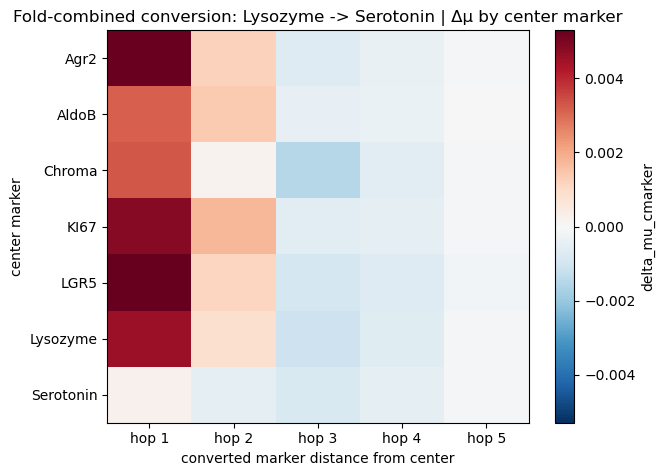

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/ablation_analysis/folded_depth5_20260605_165612/figures/fold_combined_conversion_lysozyme_to_serotonin_delta_logvar_center_by_hop.pdf and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/ablation_analysis/folded_depth5_20260605_165612/figures/fold_combined_conversion_lysozyme_to_serotonin_delta_logvar_center_by_hop.png


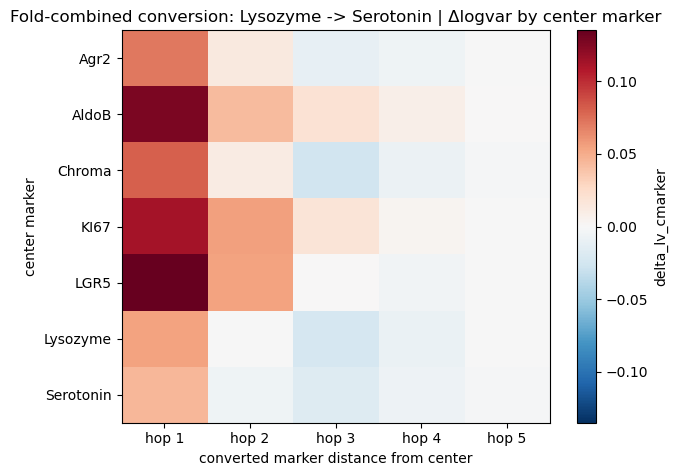

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/ablation_analysis/folded_depth5_20260605_165612/figures/fold_combined_conversion_serotonin_to_lysozyme_delta_mu_center_by_hop.pdf and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/ablation_analysis/folded_depth5_20260605_165612/figures/fold_combined_conversion_serotonin_to_lysozyme_delta_mu_center_by_hop.png


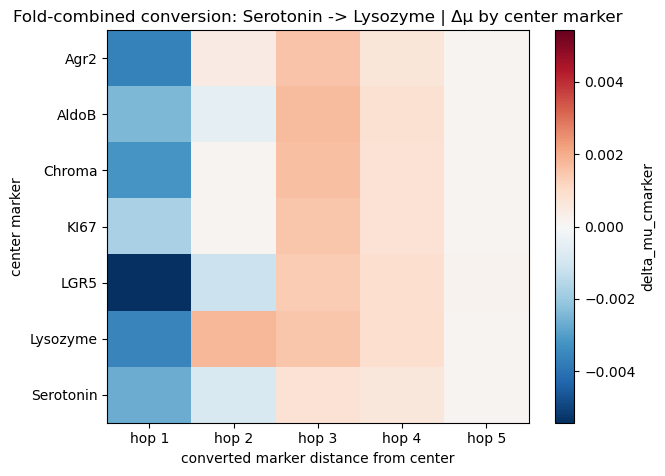

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/ablation_analysis/folded_depth5_20260605_165612/figures/fold_combined_conversion_serotonin_to_lysozyme_delta_logvar_center_by_hop.pdf and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/ablation_analysis/folded_depth5_20260605_165612/figures/fold_combined_conversion_serotonin_to_lysozyme_delta_logvar_center_by_hop.png


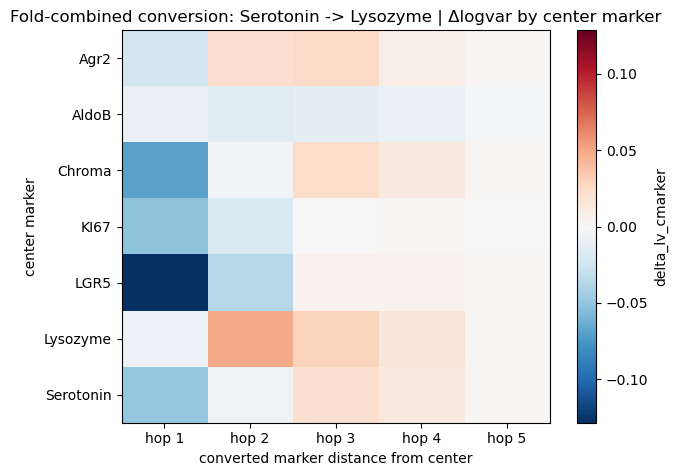

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/ablation_analysis/folded_depth5_20260605_165612/figures/fold_combined_conversion_delta_mu_total_vs_source_ablation.pdf and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/ablation_analysis/folded_depth5_20260605_165612/figures/fold_combined_conversion_delta_mu_total_vs_source_ablation.png


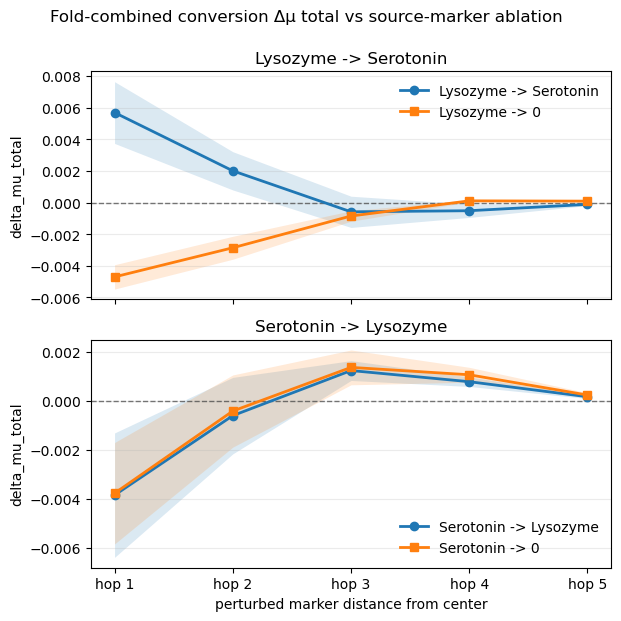

(<Figure size 640x620 with 2 Axes>,
 array([<Axes: title={'center': 'Lysozyme -> Serotonin'}, ylabel='delta_mu_total'>,
        <Axes: title={'center': 'Serotonin -> Lysozyme'}, xlabel='perturbed marker distance from center', ylabel='delta_mu_total'>],
       dtype=object))

In [30]:
for spec in CONVERSION_SPECS:
    result = combined_conversions[spec["key"]]
    plot_center_by_hop_conversion(
        result,
        spec,
        "delta_mu_cmarker",
        f"Fold-combined conversion: {spec['label']} | Δμ by center marker",
        f"fold_combined_conversion_{spec['key']}_delta_mu_center_by_hop",
    )
    plot_center_by_hop_conversion(
        result,
        spec,
        "delta_lv_cmarker",
        f"Fold-combined conversion: {spec['label']} | Δlogvar by center marker",
        f"fold_combined_conversion_{spec['key']}_delta_logvar_center_by_hop",
    )

plot_conversion_delta_mu_total_comparison(
    fold_results,
    combined_ablation,
    combined_conversions,
    CONVERSION_SPECS,
    "fold_combined_conversion_delta_mu_total_vs_source_ablation",
)


## 7. Compact Tables


In [31]:
def ablation_summary_table(result):
    rows = []
    for hi, hop in enumerate(result["hops"]):
        for mi, marker in enumerate(marker_names):
            rows.append({
                "perturbation": "ablation",
                "hop": int(hop),
                "marker": marker,
                "delta_mu": float(result["delta_mu_total"][hi, mi]),
                "delta_logvar": float(result["delta_lv_total"][hi, mi]),
                "counts": int(result["counts_total"][hi, mi]),
                "cases": int(result["cases_total"][hi, mi]),
            })
    return pd.DataFrame(rows)


def conversion_summary_table(result, spec):
    rows = []
    for hi, hop in enumerate(result["hops"]):
        for source, target in spec_pair_indices(spec):
            rows.append({
                "perturbation": spec["key"],
                "label": spec["label"],
                "hop": int(hop),
                "source_marker": marker_names[source],
                "target_marker": marker_names[target],
                "delta_mu": float(result["delta_mu_total"][hi, source, target]),
                "delta_logvar": float(result["delta_lv_total"][hi, source, target]),
                "counts": int(result["counts_total"][hi, source, target]),
                "cases": int(result["cases_total"][hi, source, target]),
            })
    return pd.DataFrame(rows)


ablation_summary_df = ablation_summary_table(combined_ablation)
conversion_summary_df = pd.concat(
    [conversion_summary_table(combined_conversions[spec["key"]], spec) for spec in CONVERSION_SPECS],
    ignore_index=True,
)

display(prediction_summary_df)
display(ablation_summary_df.head(12))
display(conversion_summary_df)


,fold,n_val_nodes,val_mse,val_mae,n_train_graphs,n_val_graphs
0,0,65245,0.002099,0.031057,564,142
1,1,68469,0.001996,0.030062,565,141
2,2,72716,0.001935,0.030101,565,141
3,3,68273,0.001876,0.029294,565,141
4,4,63680,0.002139,0.030987,565,141


,perturbation,hop,marker,delta_mu,delta_logvar,counts,cases
0,ablation,1,Agr2,-0.001573,0.005302,2923,2923
1,ablation,1,AldoB,0.002048,0.043090,6234,6234
2,ablation,1,Chroma,-0.001223,-0.034044,881,881
3,ablation,1,KI67,-0.000784,0.009068,7287,7287
4,ablation,1,LGR5,-0.001345,-0.007205,3897,3897
5,ablation,1,Lysozyme,-0.004700,-0.023418,1195,1195
6,ablation,1,Serotonin,-0.003770,-0.018975,787,787
7,ablation,2,Agr2,0.000133,0.007757,4670,4670
8,ablation,2,AldoB,0.001625,-0.003876,7233,7233
9,ablation,2,Chroma,0.000687,-0.004475,1083,1083


,perturbation,label,hop,source_marker,target_marker,delta_mu,delta_logvar,counts,cases
0,lysozyme_to_serotonin,Lysozyme -> Serotonin,1,Lysozyme,Serotonin,0.005693,0.118362,1195,1195
1,lysozyme_to_serotonin,Lysozyme -> Serotonin,2,Lysozyme,Serotonin,0.002009,0.056812,1969,1969
2,lysozyme_to_serotonin,Lysozyme -> Serotonin,3,Lysozyme,Serotonin,-0.000584,0.020154,2686,2686
3,lysozyme_to_serotonin,Lysozyme -> Serotonin,4,Lysozyme,Serotonin,-0.000514,0.004801,3336,3336
4,lysozyme_to_serotonin,Lysozyme -> Serotonin,5,Lysozyme,Serotonin,-0.000114,0.000558,3789,3789
5,serotonin_to_lysozyme,Serotonin -> Lysozyme,1,Serotonin,Lysozyme,-0.003847,-0.071206,787,787
6,serotonin_to_lysozyme,Serotonin -> Lysozyme,2,Serotonin,Lysozyme,-0.000610,-0.025945,990,990
7,serotonin_to_lysozyme,Serotonin -> Lysozyme,3,Serotonin,Lysozyme,0.001225,-0.002763,1088,1088
8,serotonin_to_lysozyme,Serotonin -> Lysozyme,4,Serotonin,Lysozyme,0.000772,-0.000858,1302,1302
9,serotonin_to_lysozyme,Serotonin -> Lysozyme,5,Serotonin,Lysozyme,0.000158,-0.000305,1375,1375


## 8. Save Results


In [32]:
ablation_summary_df.to_csv(TABLES_DIR / "fold_combined_ablation_summary.csv", index=False)
conversion_summary_df.to_csv(TABLES_DIR / "fold_combined_conversion_summary.csv", index=False)
prediction_summary_df.to_csv(TABLES_DIR / "fold_prediction_summary.csv", index=False)
fold_summary_df.to_csv(TABLES_DIR / "fold_summary.csv", index=False)

joint_config = {
    "experiment_group": EXPERIMENT_GROUP,
    "dataset_name": DATASET_NAME,
    "target_indices": TARGET_INDICES,
    "target_index_for_analysis": TARGET_INDEX_FOR_ANALYSIS,
    "use_global_features": USE_GLOBAL_FEATURES,
    "filter_blacklisted_organoids": FILTER_BLACKLISTED_ORGANOIDS,
    "subtract_constant_global_baseline": SUBTRACT_CONSTANT_GLOBAL_BASELINE,
    "n_folds": N_FOLDS,
    "fold_seed": FOLD_SEED,
    "num_layers": NUM_LAYERS,
    "model": {
        "class": MODEL_CLASS,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "norm": NORM,
        "residual": RESIDUAL,
    },
    "training": {
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "num_workers": NUM_WORKERS,
        "edge_loss_weight": EDGE_LOSS_WEIGHT,
        "edge_loss_params": EDGE_LOSS_PARAMS,
    },
    "filtering": {
        "timepoint_filter_mode": TIMEPOINT_FILTER_MODE,
        "day3p5_timepoint": DAY3P5_TIMEPOINT,
        "filter_blacklisted_organoids": FILTER_BLACKLISTED_ORGANOIDS,
        "blacklist_n_keys": len(blacklist),
        "fill_missing_complexity": FILL_MISSING_COMPLEXITY,
        "missing_complexity_group": MISSING_COMPLEXITY_GROUP,
        "sphericity_max": SPHERICITY_MAX,
        "spherical_marker_diversity_min": SPHERICAL_MARKER_DIVERSITY_MIN,
        "complexity_min": COMPLEXITY_MIN,
        "interpolate_target_outliers": INTERPOLATE_TARGET_OUTLIERS,
        "outlier_clip_quantiles": OUTLIER_CLIP_QUANTILES,
        "spherical_rescue_enabled": False,
    },
    "perturbation": {
        "mode": PERTURBATION_MODE,
        "max_subgraphs_per_fold": MAX_SUBGRAPHS_PER_FOLD,
        "min_center_count": MIN_CENTER_COUNT,
        "min_pair_count": MIN_PAIR_COUNT,
        "heatmap_min_count": HEATMAP_MIN_COUNT,
        "subgraph_seed": SUBGRAPH_SEED,
        "batch_size": PERTURB_BATCH_SIZE,
        "normalize_by": NORMALIZE_BY,
        "conversion_specs": CONVERSION_SPECS,
    },
    "n_graphs_after_filtering": len(graphs),
    "marker_names": list(marker_names),
    "field_specs": field_specs,
    "figures_dir": str(FIGURES_DIR),
    "tables_dir": str(TABLES_DIR),
}

results_by_experiment = {
    "fold_summary_df": fold_summary_df,
    "prediction_summary_df": prediction_summary_df,
    "ablation_summary_df": ablation_summary_df,
    "conversion_summary_df": conversion_summary_df,
    "combined_ablation": combined_ablation,
    "combined_conversions": combined_conversions,
    "training_logs": training_logs,
    "sampling_results": sampling_results,
    "fold_results": fold_results,
    "outlier_info": outlier_info,
}

SAVE_DIR.mkdir(parents=True, exist_ok=True)
with open(SAVE_DIR / "config.json", "w") as f:
    json.dump(jsonable(joint_config), f, indent=2)
with open(SAVE_DIR / "results.pkl", "wb") as f:
    pickle.dump(results_by_experiment, f)
with open(SAVE_DIR / "meta.json", "w") as f:
    json.dump(
        jsonable({
            "timestamp": datetime.now().isoformat(),
            "notes": "Fold-combined ablation and conversion analysis for one depth-4 GIN model per fold.",
        }),
        f,
        indent=2,
    )

print(f"Saved folded ablation/conversion experiment -> {SAVE_DIR}")


Saved folded ablation/conversion experiment -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/ablation_analysis/folded_depth5_20260605_165612
